# Лабораторная работа №6

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor,
                              RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              AdaBoostClassifier, AdaBoostRegressor,
                              StackingClassifier, StackingRegressor)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, RocCurveDisplay, classification_report)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression, RFE
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap
from sklearn.utils import resample
import umap

import optuna

RNG_SEED = 42
np.random.seed(RNG_SEED)

### Загрузка датасетов

In [29]:
df_wine = pd.read_csv('../data/final_data_wine.csv', index_col=0)
df_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
1,0.477600,3.405904,-2.279442,-0.601255,2.344580,-0.322206,-0.876417,0.751612,-0.125112,1.160428,-0.603680,5,1
2,0.477600,2.657618,-1.988649,-0.664982,2.042786,-0.901443,-1.109439,0.819769,0.249064,0.936303,-0.603680,5,1
3,3.140279,-0.335528,1.791656,-0.749952,1.187702,-0.785596,-1.001890,1.160613,-0.374562,0.413346,-0.603680,6,1
4,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,-0.775426,-0.772028,-0.171195,-0.813679,-0.623063,-0.380130,-0.428298,-1.177475,0.311427,-0.184319,0.568742,6,0
4894,-0.462170,-0.086099,0.337693,0.545837,-0.220671,1.531351,0.933984,0.104033,-0.436925,-0.483152,-0.771169,5,0
4895,-0.540484,-0.584956,-0.898176,-0.898649,-0.522465,-0.032588,-0.087728,-0.700317,-1.434728,-0.483152,-0.938658,6,0
4896,-1.323625,-0.273170,-0.098496,-0.919892,-1.478147,-0.611825,-0.105652,-2.012500,0.747965,-1.080818,1.908654,7,0


In [30]:
df_wine.info()

<class 'pandas.DataFrame'>
Index: 5974 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         5974 non-null   float64
 1   volatile acidity      5974 non-null   float64
 2   citric acid           5974 non-null   float64
 3   residual sugar        5974 non-null   float64
 4   chlorides             5974 non-null   float64
 5   free sulfur dioxide   5974 non-null   float64
 6   total sulfur dioxide  5974 non-null   float64
 7   density               5974 non-null   float64
 8   pH                    5974 non-null   float64
 9   sulphates             5974 non-null   float64
 10  alcohol               5974 non-null   float64
 11  quality               5974 non-null   int64  
 12  type                  5974 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 653.4 KB


In [31]:
df_diamonds = pd.read_csv("../data/final_data_diamonds.csv", index_col=0)
df_diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,-1.199341,4,5,1,-0.176252,-1.096824,326,-1.587838,-1.573374,-1.593630
1,-1.241582,3,5,2,-1.381332,1.591635,326,-1.641325,-1.699003,-1.766179
2,-1.199341,1,5,4,-3.437054,3.383941,327,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461732,0.247406,334,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099714,0.247406,335,-1.240166,-1.241354,-1.133502
...,...,...,...,...,...,...,...,...,...,...
53935,-0.164447,4,6,2,-0.672462,-0.200671,2757,0.016798,0.023908,-0.055076
53936,-0.164447,1,6,2,0.957939,-1.096824,2757,-0.036690,0.014935,0.103093
53937,-0.206688,2,6,2,0.745278,1.143559,2757,-0.063434,-0.047880,0.031198
53938,0.131237,3,2,1,-0.530687,0.247406,2757,0.373383,0.346954,0.290021


In [32]:
df_diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  int64  
 2   color    53940 non-null  int64  
 3   clarity  53940 non-null  int64  
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 4.1 MB


**Разделение выборок**

In [ ]:
X_cls = df_wine.drop(columns=['quality', 'type'])
y_cls = df_wine['type']

X_reg = df_diamonds.drop(columns=['price'])
y_reg = df_diamonds['price']

print(f"Train sizes: cls={X_cls.shape}, reg={X_reg.shape}")

Train sizes: cls=(4779, 11), reg=(43152, 9)


## Решение задачи понижения размерности

In [ ]:
result_cls = {}
result_reg = {}

In [66]:
vt = VarianceThreshold(threshold=1)
vt.fit(X_cls)
selected_vt_cls = X_cls.columns[vt.get_support()]
print(selected_vt_cls)

vt = VarianceThreshold(threshold=1)
vt.fit(X_reg)
selected_vt_reg = X_reg.columns[vt.get_support()]
print(selected_vt_reg)

result_cls["VarianceThreshold"] = selected_vt_cls
result_reg["VarianceThreshold"] = selected_vt_reg

Index(['volatile acidity', 'citric acid', 'free sulfur dioxide', 'density',
       'pH'],
      dtype='str')
Index(['cut', 'color', 'clarity', 'y'], dtype='str')


Отобранные признаки (SelectKBest): ['chlorides', 'total sulfur dioxide']
Отобранные признаки (SelectKBest): ['x', 'y']


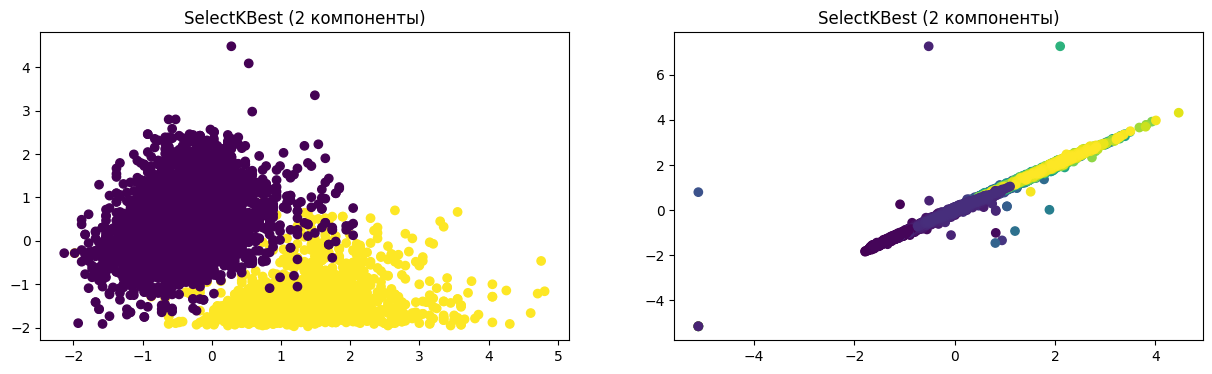

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15,4))
skb = SelectKBest(score_func=f_classif, k=2)

X_skb_cls = skb.fit_transform(X_cls, y_cls)
print("Отобранные признаки (SelectKBest):", X_cls.columns[skb.get_support()].tolist())
axes[0].scatter(X_skb_cls[:,0], X_skb_cls[:,1], c=y_cls, cmap='viridis')
axes[0].set_title('SelectKBest (2 компоненты)')

X_skb_reg = skb.fit_transform(X_reg, y_reg)
print("Отобранные признаки (SelectKBest):", X_reg.columns[skb.get_support()].tolist())
axes[1].scatter(X_skb_reg[:,0], X_skb_reg[:,1], c=y_reg, cmap='viridis')
axes[1].set_title('SelectKBest (2 компоненты)')

fig.show()


result_cls["SelectKBest"] = X_skb_cls
result_reg["SelectKBest"] = X_skb_reg

Отобранные признаки (RFE): ['chlorides', 'total sulfur dioxide']
Отобранные признаки (RFE): ['x', 'y']


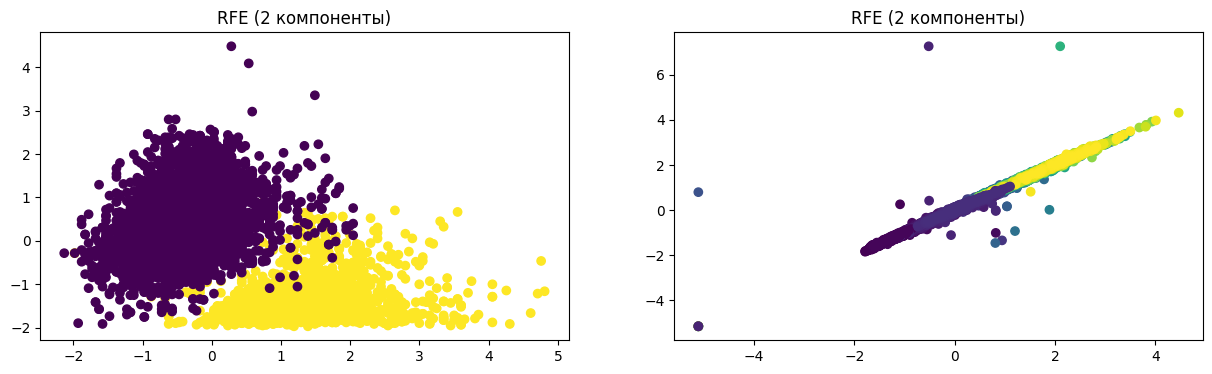

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(15,4))
rfe = RFE(estimator=LogisticRegression(max_iter=1000, solver='lbfgs'), n_features_to_select=2)

X_rfe_cls = rfe.fit_transform(X_cls, y_cls)
print("Отобранные признаки (RFE):", X_cls.columns[rfe.support_].tolist())
axes[0].scatter(X_rfe_cls[:,0], X_rfe_cls[:,1], c=y_cls, cmap='viridis')
axes[0].set_title('RFE (2 компоненты)')

X_rfe_reg = skb.fit_transform(X_reg, y_reg)
print("Отобранные признаки (RFE):", X_reg.columns[skb.get_support()].tolist())
axes[1].scatter(X_rfe_reg[:,0], X_rfe_reg[:,1], c=y_reg, cmap='viridis')
axes[1].set_title('RFE (2 компоненты)')

fig.show()

result_cls["RFE"] = X_rfe_cls
result_reg["RFE"] = X_rfe_reg

PCA: Объяснённая дисперсия: [0.29980662 0.23478063]
PCA: Объяснённая дисперсия: [0.39526874 0.22826809]


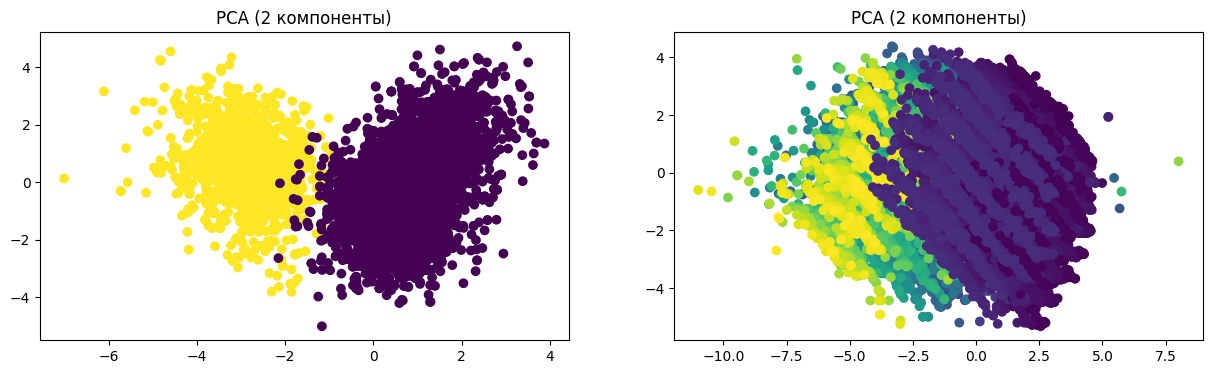

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(15,4))

pca = PCA(n_components=2)

X_pca_cls = pca.fit_transform(X_cls)
print(f"PCA: Объяснённая дисперсия: {pca.explained_variance_ratio_}")
axes[0].scatter(X_pca_cls[:,0], X_pca_cls[:,1], c=y_cls, cmap='viridis')
axes[0].set_title('PCA (2 компоненты)')

X_pca_reg = pca.fit_transform(X_reg)
print(f"PCA: Объяснённая дисперсия: {pca.explained_variance_ratio_}")
axes[1].scatter(X_pca_reg[:,0], X_pca_reg[:,1], c=y_reg, cmap='viridis')
axes[1].set_title('PCA (2 компоненты)')

fig.show()

result_cls["PCA"] = X_pca_cls
result_reg["PCA"] = X_pca_reg

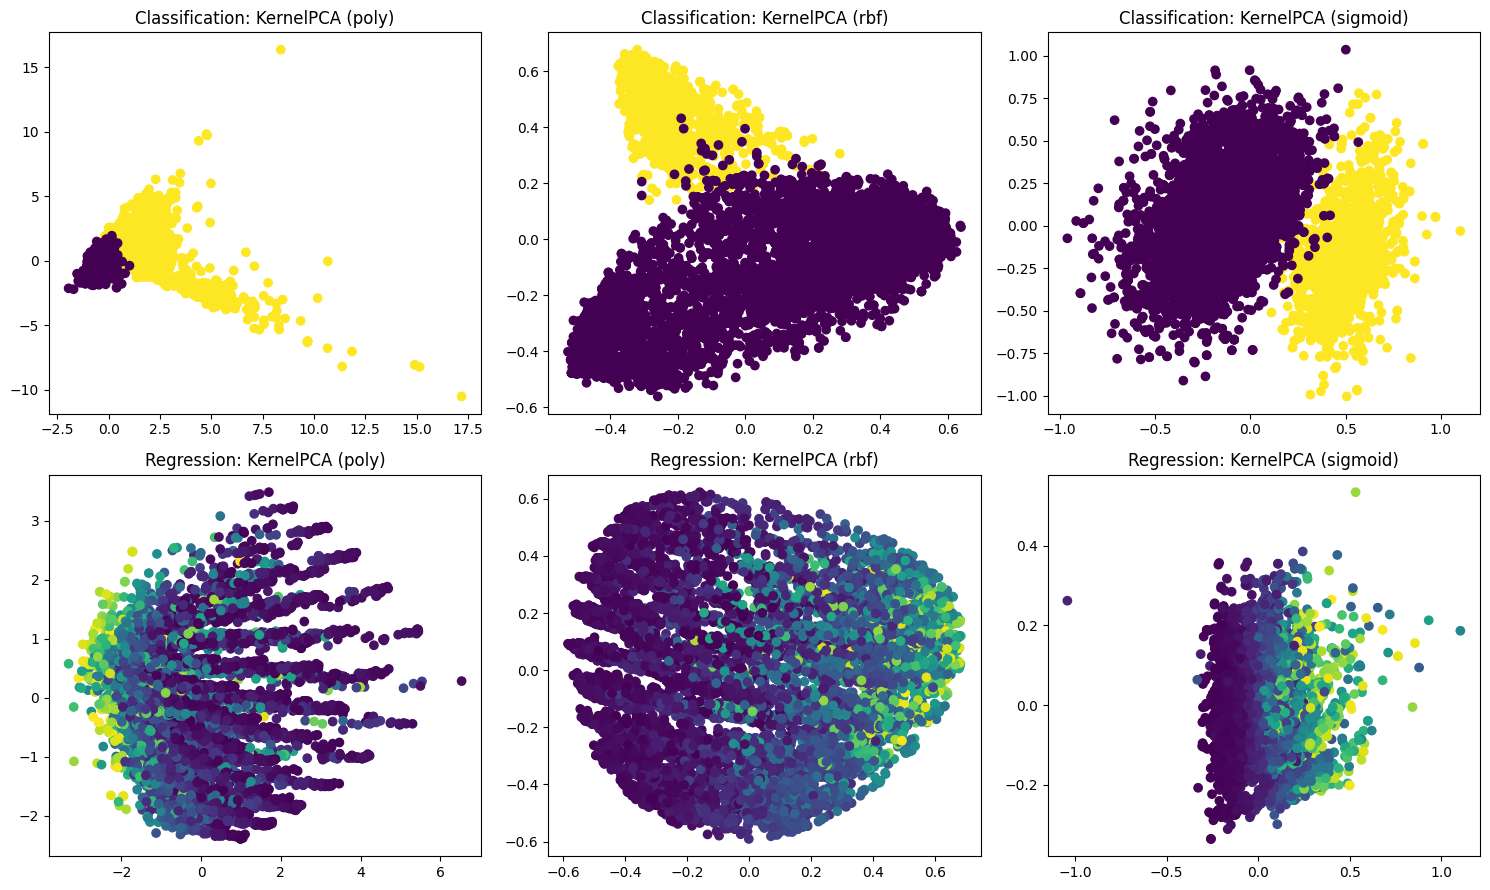

In [70]:
gamma_val_cls = 1 / (X_cls.shape[1] * np.var(X_cls))
gamma_val_reg = 1 / (X_reg.shape[1] * np.var(X_reg))

kernels = ['poly', 'rbf', 'sigmoid']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, ker in enumerate(kernels):
    kpca = KernelPCA(n_components=2, kernel=ker, gamma=gamma_val_cls)
    X_kpca = kpca.fit_transform(X_cls)
    axes[0, i].scatter(X_kpca[:,0], X_kpca[:,1], c=y_cls, cmap='viridis')
    axes[0, i].set_title(f'Classification: KernelPCA ({ker})')
    result_cls[f"PCA {ker}"] = X_kpca

n_samples = 10000
X_reg_sub, y_reg_sub = resample(X_reg, y_reg, 
                                n_samples=n_samples, random_state=42)

for i, ker in enumerate(kernels):
    kpca = KernelPCA(n_components=2, kernel=ker, gamma=gamma_val_reg)
    X_kpca = kpca.fit_transform(X_reg_sub)
    axes[1, i].scatter(X_kpca[:,0], X_kpca[:,1], c=y_reg_sub, cmap='viridis')
    axes[1, i].set_title(f'Regression: KernelPCA ({ker})')
    result_reg[f"PCA {ker}"] = X_kpca

plt.tight_layout()
plt.show()


result_reg["PCA"] = X_pca_reg

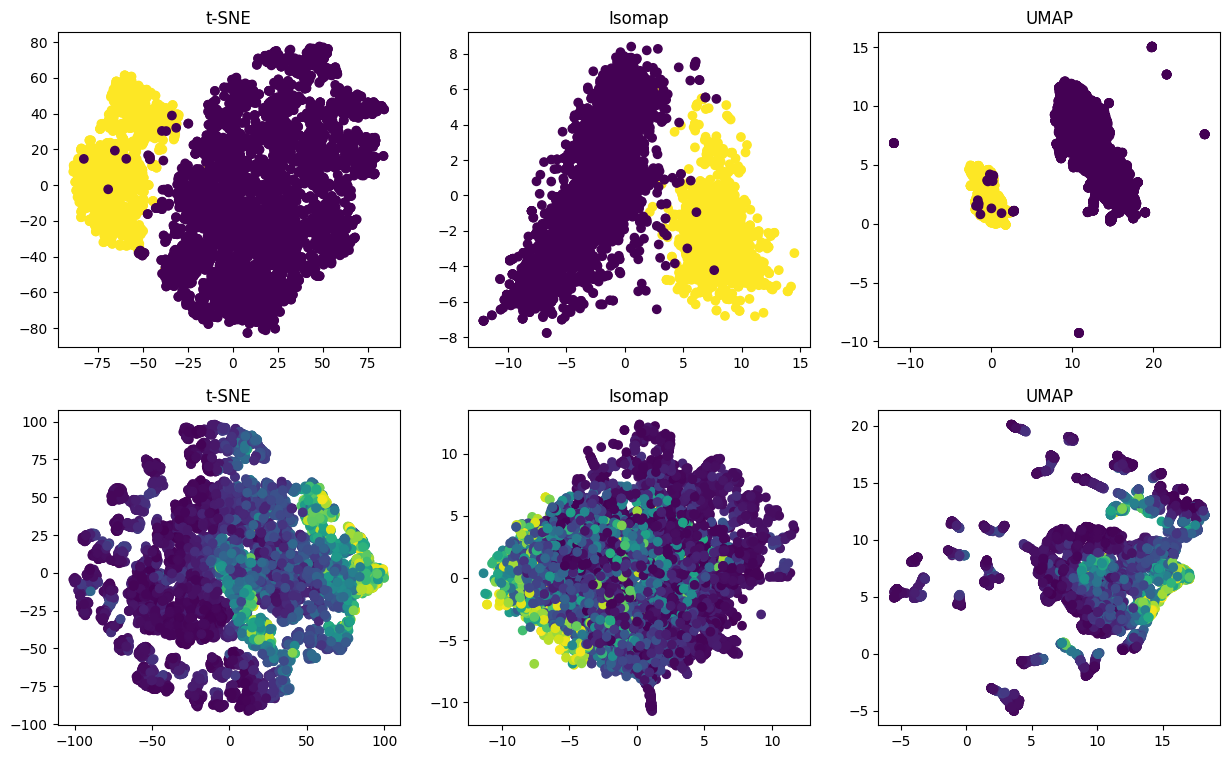

In [81]:
fig, axes = plt.subplots(2, 3, figsize=(15,9))

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_cls)
axes[0, 0].scatter(X_tsne[:,0], X_tsne[:,1], c=y_cls, cmap='viridis')
axes[0, 0].set_title('t-SNE')
result_cls["TSNE"] = X_tsne

isomap = Isomap(n_components=2, n_neighbors=5)
X_isomap = isomap.fit_transform(X_cls)
axes[0, 1].scatter(X_isomap[:,0], X_isomap[:,1], c=y_cls, cmap='viridis')
axes[0, 1].set_title('Isomap')
result_cls["Isomap"] = X_isomap

umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X_cls)
axes[0, 2].scatter(X_umap[:,0], X_umap[:,1], c=y_cls, cmap='viridis')
axes[0, 2].set_title('UMAP')
result_cls["UMAP"] = X_umap

n_samples = 10000
X_reg_sub, y_reg_sub = resample(X_reg, y_reg, 
                                n_samples=n_samples, random_state=42)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_reg_sub)
axes[1, 0].scatter(X_tsne[:,0], X_tsne[:,1], c=y_reg_sub, cmap='viridis')
axes[1, 0].set_title('t-SNE')
result_reg["TSNE"] = X_tsne

isomap = Isomap(n_components=2, n_neighbors=5)
X_isomap = isomap.fit_transform(X_reg_sub)
axes[1, 1].scatter(X_isomap[:,0], X_isomap[:,1], c=y_reg_sub, cmap='viridis')
axes[1, 1].set_title('Isomap')
result_reg["Isomap"] = X_isomap

umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X_reg_sub)
axes[1, 2].scatter(X_umap[:,0], X_umap[:,1], c=y_reg_sub, cmap='viridis')
axes[1, 2].set_title('UMAP')
result_reg["TSNE"] = X_tsne

In [86]:
print(result_cls)
print(result_reg)

{'VarianceThreshold': Index(['volatile acidity', 'citric acid', 'free sulfur dioxide', 'density',
       'pH'],
      dtype='str'), 'SelectKBest': array([[ 1.2380011 , -1.46793396],
       [ 2.34458   , -0.87641691],
       [ 2.042786  , -1.10943878],
       ...,
       [-0.5224649 , -0.0877275 ],
       [-1.4781466 , -0.10565226],
       [-1.5787446 , -0.32074937]], shape=(5974, 2)), 'RFE': array([[ 1.2380011 , -1.46793396],
       [ 2.34458   , -0.87641691],
       [ 2.042786  , -1.10943878],
       ...,
       [-0.5224649 , -0.0877275 ],
       [-1.4781466 , -0.10565226],
       [-1.5787446 , -0.32074937]], shape=(5974, 2)), 'PCA': array([[-3.70302995,  0.33661728],
       [-3.83604521,  1.10828187],
       [-3.75509303,  0.84030283],
       ...,
       [ 0.68667549, -0.6470372 ],
       [ 0.7807469 , -3.63566187],
       [ 1.17885073, -2.95314786]], shape=(5974, 2)), 'PCA poly': array([[ 1.6605784 ,  3.64848109],
       [ 2.35565665,  3.68338786],
       [ 2.04388238,  3.06912374],

## Обучение моделей в пространстве низкой размерности
В качестве моделей выберем:
- **Классификация**: `RandomForestClassifier` (устойчив к шуму, хорошо работает с PCA)
- **Регрессия**: `Ridge` (линейная регуляризация, хорошо сочетается с PCA)

In [ ]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
reg = Ridge(alpha=1.0)

results = []

for name, data in result_cls.items():
    X_tr, X_te = data['X_train'], data['X_test']
    task = data['task']
    
        clf.fit(X_tr, y_cls_train)
        if X_te is not None:
            score = accuracy_score(y_cls_test, clf.predict(X_te))
        else:
            score = accuracy_score(y_cls_train, clf.predict(X_tr))
            
    results.append({
        'Method': name,
        'Task': task.upper(),
        'Metric': 'Accuracy' if task == 'cls' else 'R2',
        'Score': score,
        'Train Shape': X_tr.shape,
        'Test Shape': X_te.shape if X_te is not None else 'N/A'
    })

# Выводим таблицу результатов
df_results = pd.DataFrame(results)
print("\n📊 Результаты сравнения методов:")
print(df_results.to_string(index=False))

ValueError: Found input variables with inconsistent numbers of samples: [5974, 4779]

In [ ]:
# --- РЕГРЕССИЯ ---
# Используем PCA (3 компоненты) для набора diamonds
pca_reg = PCA(n_components=3)
X_reg_train_pca = pca_reg.fit_transform(scaler_reg.fit_transform(X_reg_train))
X_reg_test_pca = pca_reg.transform(scaler_reg.transform(X_reg_test))

reg_ridge = Ridge(alpha=1.0)
reg_ridge.fit(X_reg_train_pca, y_reg_train)
y_reg_pred = reg_ridge.predict(X_reg_test_pca)

print("\n=== Регрессия (PCA + Ridge) ===")
print(f"MSE: {mean_squared_error(y_reg_test, y_reg_pred):.2f}")
print(f"R2 Score: {r2_score(y_reg_test, y_reg_pred):.2f}")